In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score, f1_score, confusion_matrix
from collections import Counter

In [ ]:
import pandas as pd
df= pd.read_csv ("/content/drive/MyDrive/Electric_Vehicle_Population_Data.csv")
df.head()


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EA0K,Thurston,Tumwater,WA,98512.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,55000.0,22.0,242565116,POINT (-122.91310169999997 47.01359260000004),PUGET SOUND ENERGY INC,"53,067,010,910.00"
1,1N4BZ1DV4N,Island,Clinton,WA,98236.0,2022,NISSAN,LEAF,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,59000.0,10.0,183272785,POINT (-122.35936399999997 47.97965520000008),PUGET SOUND ENERGY INC,"53,029,972,000.00"
2,5YJ3E1EA0L,Snohomish,Snohomish,WA,98290.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,59000.0,44.0,112552366,POINT (-122.09150499999998 47.91555500000004),PUGET SOUND ENERGY INC,"53,061,052,502.00"
3,5YJ3E1EBXL,King,Seattle,WA,98134.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322.0,59000.0,11.0,6336319,POINT (-122.32981499999994 47.579810000000066),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),"53,033,009,300.00"
4,5YJSA1CP0D,Snohomish,Edmonds,WA,98020.0,2013,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,69900.0,21.0,186212960,POINT (-122.37507 47.80807000000004),PUGET SOUND ENERGY INC,"53,061,050,403.00"


# New Section

In [ ]:
# to check data types, shape and non null values of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135038 entries, 0 to 135037
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         135038 non-null  object 
 1   County                                             135030 non-null  object 
 2   City                                               135030 non-null  object 
 3   State                                              135038 non-null  object 
 4   Postal Code                                        135030 non-null  float64
 5   Model Year                                         135038 non-null  int64  
 6   Make                                               135038 non-null  object 
 7   Model                                              134789 non-null  object 
 8   Electric Vehicle Type                              135038 non-null  object

In [ ]:
# to check all statistical information
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID
count,135030.000000,135038.000000,135037.000000,135037.000000,134726.000000,1.350380e+05
mean,98171.001577,2019.662880,74.868873,2907.800381,29.504379,2.063432e+08
std,2450.367211,3.001676,98.822312,13203.268093,14.783780,8.582417e+07
min,1730.000000,1997.000000,0.000000,0.000000,1.000000,4.385000e+03
25%,98052.000000,2018.000000,0.000000,0.000000,18.000000,1.606305e+08
50%,98121.000000,2021.000000,21.000000,0.000000,34.000000,2.059563e+08
75%,98370.000000,2022.000000,150.000000,0.000000,43.000000,2.308888e+08
max,99701.000000,2024.000000,337.000000,845000.000000,49.000000,4.792548e+08


In [ ]:
# how many null values
df.isnull().sum()

,0
VIN (1-10),0
County,8
City,8
State,0
Postal Code,8
Model Year,0
Make,0
Model,249
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


In [ ]:
# CLEAN AND PREPARE THE DATA
Target= "Electric Vehicle Type"
Features= ["Make", "Model", "Model Year", "County"]
x = df[Features].copy()
y = df[Target].copy()
print(x,y)

           Make    Model  Model Year     County
0         TESLA  MODEL 3        2019   Thurston
1        NISSAN     LEAF        2022     Island
2         TESLA  MODEL 3        2020  Snohomish
3         TESLA  MODEL 3        2020       King
4         TESLA  MODEL S        2013  Snohomish
...         ...      ...         ...        ...
135033    TESLA  MODEL S        2020       King
135034    TESLA  MODEL Y        2021       King
135035    TESLA  MODEL S        2022     Pierce
135036  HYUNDAI  IONIQ 5        2023      Grant
135037     FORD    C-MAX        2014     Kitsap

[135038 rows x 4 columns] 0                 Battery Electric Vehicle (BEV)
1                 Battery Electric Vehicle (BEV)
2                 Battery Electric Vehicle (BEV)
3                 Battery Electric Vehicle (BEV)
4                 Battery Electric Vehicle (BEV)
                           ...                  
135033            Battery Electric Vehicle (BEV)
135034            Battery Electric Vehicle (BEV)
13503

In [ ]:
# Drop any rows that have missing values in these specific columns
df_clean= df[Features + [Target]].copy()
df_clean= df_clean.dropna()
df_clean

,Make,Model,Model Year,County,Electric Vehicle Type
0,TESLA,MODEL 3,2019,Thurston,Battery Electric Vehicle (BEV)
1,NISSAN,LEAF,2022,Island,Battery Electric Vehicle (BEV)
2,TESLA,MODEL 3,2020,Snohomish,Battery Electric Vehicle (BEV)
3,TESLA,MODEL 3,2020,King,Battery Electric Vehicle (BEV)
4,TESLA,MODEL S,2013,Snohomish,Battery Electric Vehicle (BEV)
...,...,...,...,...,...
135033,TESLA,MODEL S,2020,King,Battery Electric Vehicle (BEV)
135034,TESLA,MODEL Y,2021,King,Battery Electric Vehicle (BEV)
135035,TESLA,MODEL S,2022,Pierce,Battery Electric Vehicle (BEV)
135036,HYUNDAI,IONIQ 5,2023,Grant,Battery Electric Vehicle (BEV)


In [ ]:
# Calculate the median year and fill in the blanks
median_year= df_clean["Model Year"].median()
df_clean["Model Year"]= df_clean["Model Year"].fillna(median_year)
df_clean["Model Year"]

,Model Year
0,2019
1,2022
2,2020
3,2020
4,2013
...,...
135033,2020
135034,2021
135035,2022
135036,2023


In [ ]:
# Fill missing text ('County') with a placeholder string
df_clean['County'] = df_clean['County'].fillna('Unknown')
df_clean['County']

,County
0,Thurston
1,Island
2,Snohomish
3,King
4,Snohomish
...,...
135033,King
135034,King
135035,Pierce
135036,Grant


In [ ]:
# Drop the row ONLY if the Target, Make, or Model is missing
df_clean = df_clean.dropna(subset=[Target, 'Make', 'Model'])
df_clean

,Make,Model,Model Year,County,Electric Vehicle Type
0,TESLA,MODEL 3,2019,Thurston,Battery Electric Vehicle (BEV)
1,NISSAN,LEAF,2022,Island,Battery Electric Vehicle (BEV)
2,TESLA,MODEL 3,2020,Snohomish,Battery Electric Vehicle (BEV)
3,TESLA,MODEL 3,2020,King,Battery Electric Vehicle (BEV)
4,TESLA,MODEL S,2013,Snohomish,Battery Electric Vehicle (BEV)
...,...,...,...,...,...
135033,TESLA,MODEL S,2020,King,Battery Electric Vehicle (BEV)
135034,TESLA,MODEL Y,2021,King,Battery Electric Vehicle (BEV)
135035,TESLA,MODEL S,2022,Pierce,Battery Electric Vehicle (BEV)
135036,HYUNDAI,IONIQ 5,2023,Grant,Battery Electric Vehicle (BEV)


In [ ]:
# Feature Engineering for this data
import datetime

# 1. Vehicle age instead of raw model year
df_clean["Vehicle Age"] = datetime.datetime.now().year - df_clean["Model Year"]
df_clean["Vehicle Age"]


,Vehicle Age
0,7
1,4
2,6
3,6
4,13
...,...
135033,6
135034,5
135035,4
135036,3


In [ ]:
# 2. Collapse "Model" into a frequency count instead of 150+ one-hot columns
model_counts = df_clean["Model"].value_counts()
print(model_counts)

df_clean["Model_Frequency"] = df_clean["Model"].map(model_counts)
df_clean["Model_Frequency"]

Model
MODEL 3        25835
MODEL Y        23575
LEAF           13019
MODEL S         7473
BOLT EV         5419
               ...  
A8 E               2
FLYING SPUR        1
918                1
Q8                 1
S-10 PICKUP        1
Name: count, Length: 125, dtype: int64


,Model_Frequency
0,25835
1,13019
2,25835
3,25835
4,7473
...,...
135033,7473
135034,23575
135035,7473
135036,1236


In [ ]:
# 3. Group County into fewer regions (reduces one-hot columns, keeps geography signal)
puget_sound = ["King", "Snohomish", "Pierce", "Kitsap", "Thurston"]
print(puget_sound)

df_clean["Region"] = df_clean["County"].apply(lambda c: "Puget Sound" if c in puget_sound else "Other WA")
print(df_clean["Region"])

['King', 'Snohomish', 'Pierce', 'Kitsap', 'Thurston']
0         Puget Sound
1            Other WA
2         Puget Sound
3         Puget Sound
4         Puget Sound
             ...     
135033    Puget Sound
135034    Puget Sound
135035    Puget Sound
135036       Other WA
135037    Puget Sound
Name: Region, Length: 134781, dtype: object


In [ ]:
# 4. Base MSRP dropped entirely — 94.8% of rows have it as 0 (unreported), not a real price signal
Features = ["Make", "Region", "Vehicle Age", "Model_Frequency"]
print(Features)

['Make', 'Region', 'Vehicle Age', 'Model_Frequency']


In [ ]:
# One-hot encode the feature columns
x = pd.get_dummies(df_clean[Features], columns=["Make", "Region"])
print(x)

        Vehicle Age  Model_Frequency  Make_AUDI  Make_AZURE DYNAMICS  \
0                 7            25835      False                False   
1                 4            13019      False                False   
2                 6            25835      False                False   
3                 6            25835      False                False   
4                13             7473      False                False   
...             ...              ...        ...                  ...   
135033            6             7473      False                False   
135034            5            23575      False                False   
135035            4             7473      False                False   
135036            3             1236      False                False   
135037           12             1546      False                False   

        Make_BENTLEY  Make_BMW  Make_CADILLAC  Make_CHEVROLET  Make_CHRYSLER  \
0              False     False          False          

In [ ]:
# Need simple label encoding (BEV/PHEV -> 0/1, not one-hot)
from sklearn.preprocessing import LabelEncoder
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(df_clean[Target])
print(y)

[0 0 0 ... 0 0 1]


In [ ]:
# Split the Data into Training and Testing Sets
# We set aside 20% of the data to test the model later
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state= 42, stratify=y)

print(f"Training on{len(x_train)} cars, Testing on {len(x_test)} cars.")


Training on107824 cars, Testing on 26957 cars.


In [ ]:
# Build and Train the Decision Tree
from sklearn.tree import DecisionTreeClassifier
tree_model= DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
tree_model.fit(x_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=4, random_state=42)

In [ ]:
# Check Accuracy AND the per-class report
# Ask the model to predict the vehicle types for our test set
predictions= tree_model.predict(x_test)
print(predictions)

[0 0 1 ... 1 1 1]


In [ ]:
# Check how accurate the predictions were
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

Model Accuracy: 85.50%



In [ ]:
# Print a detailed report showing Precision, Recall, and F1-Score
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, tree_model.predict(x_test), target_names=y_encoder.classes_))

                                        precision    recall  f1-score   support

        Battery Electric Vehicle (BEV)       1.00      0.81      0.90     20726
Plug-in Hybrid Electric Vehicle (PHEV)       0.61      1.00      0.76      6231

                              accuracy                           0.85     26957
                             macro avg       0.81      0.91      0.83     26957
                          weighted avg       0.91      0.85      0.86     26957



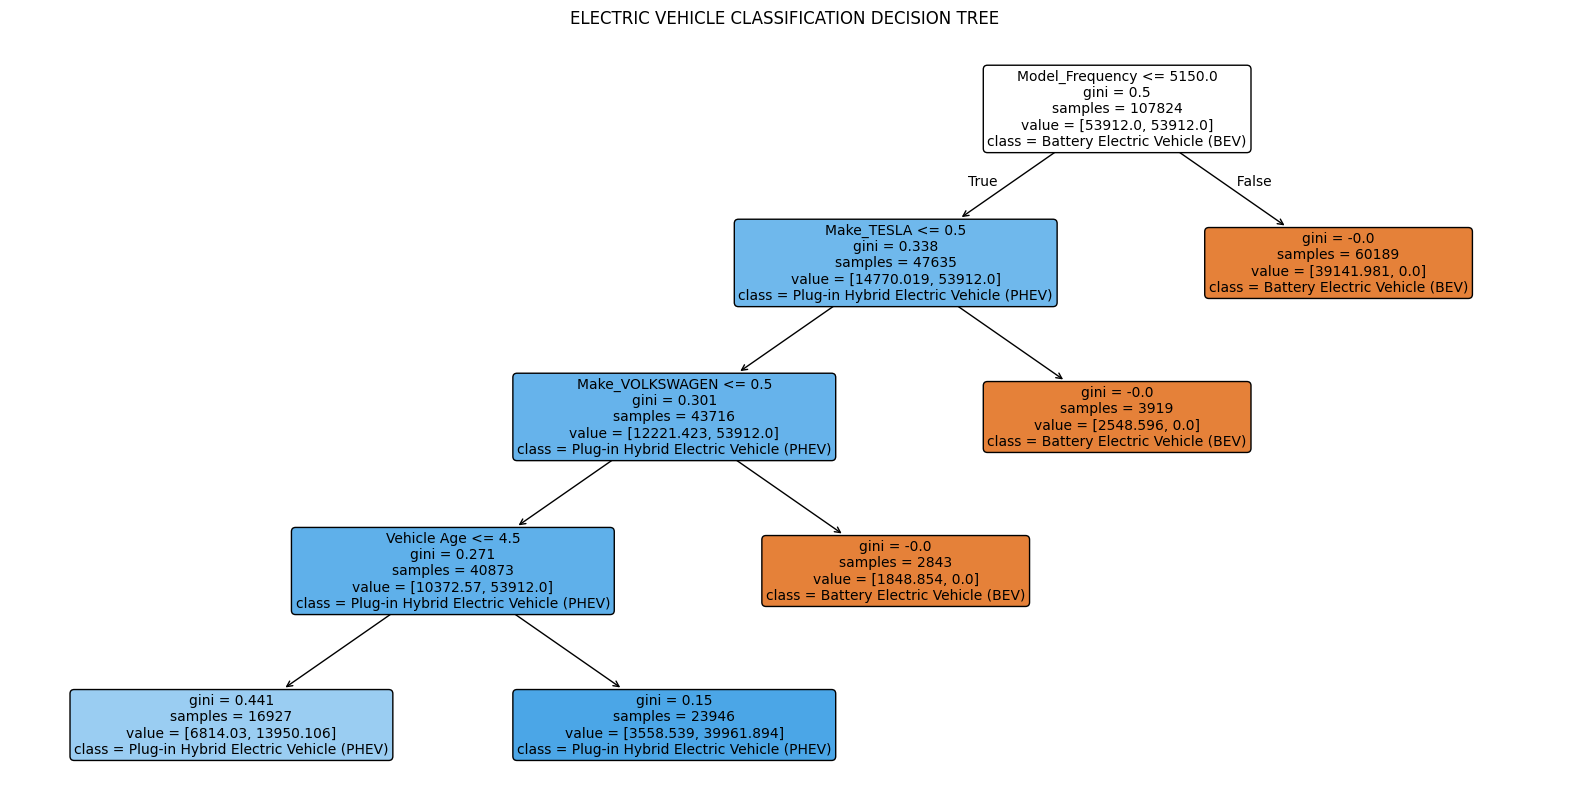

In [ ]:
# Electric Vehicle Classification Decision Tree
from sklearn.tree import plot_tree
from matplotlib import pyplot as plt
plt.figure(figsize=(20, 10))
plot_tree(tree_model,
          feature_names=x_train.columns,
          class_names=y_encoder.classes_,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("ELECTRIC VEHICLE CLASSIFICATION DECISION TREE")
plt.show()

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, tree_model.predict(x_test)))

[[16816  3910]
 [    0  6231]]


In [ ]:
# Train accuracy vs. test accuracy — check for overfitting
print("Train accuracy:", tree_model.score(x_train, y_train))
print("Test accuracy:", tree_model.score(x_test, y_test))

Train accuracy: 0.8520737498145126
Test accuracy: 0.8549541862966947


In [ ]:
# Compare against a "dumb" baseline
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(x_train, y_train)
print("Baseline (always guess BEV):", dummy.score(x_test, y_test))

Baseline (always guess BEV): 0.7688541009756279


In [ ]:
 # Try a Random Forest for comparison
 from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(n_estimators=100, max_depth=4, class_weight="balanced", random_state=42)
forest.fit(x_train, y_train)
print("Random Forest accuracy:", forest.score(x_test, y_test))

Random Forest accuracy: 0.8387431835886783


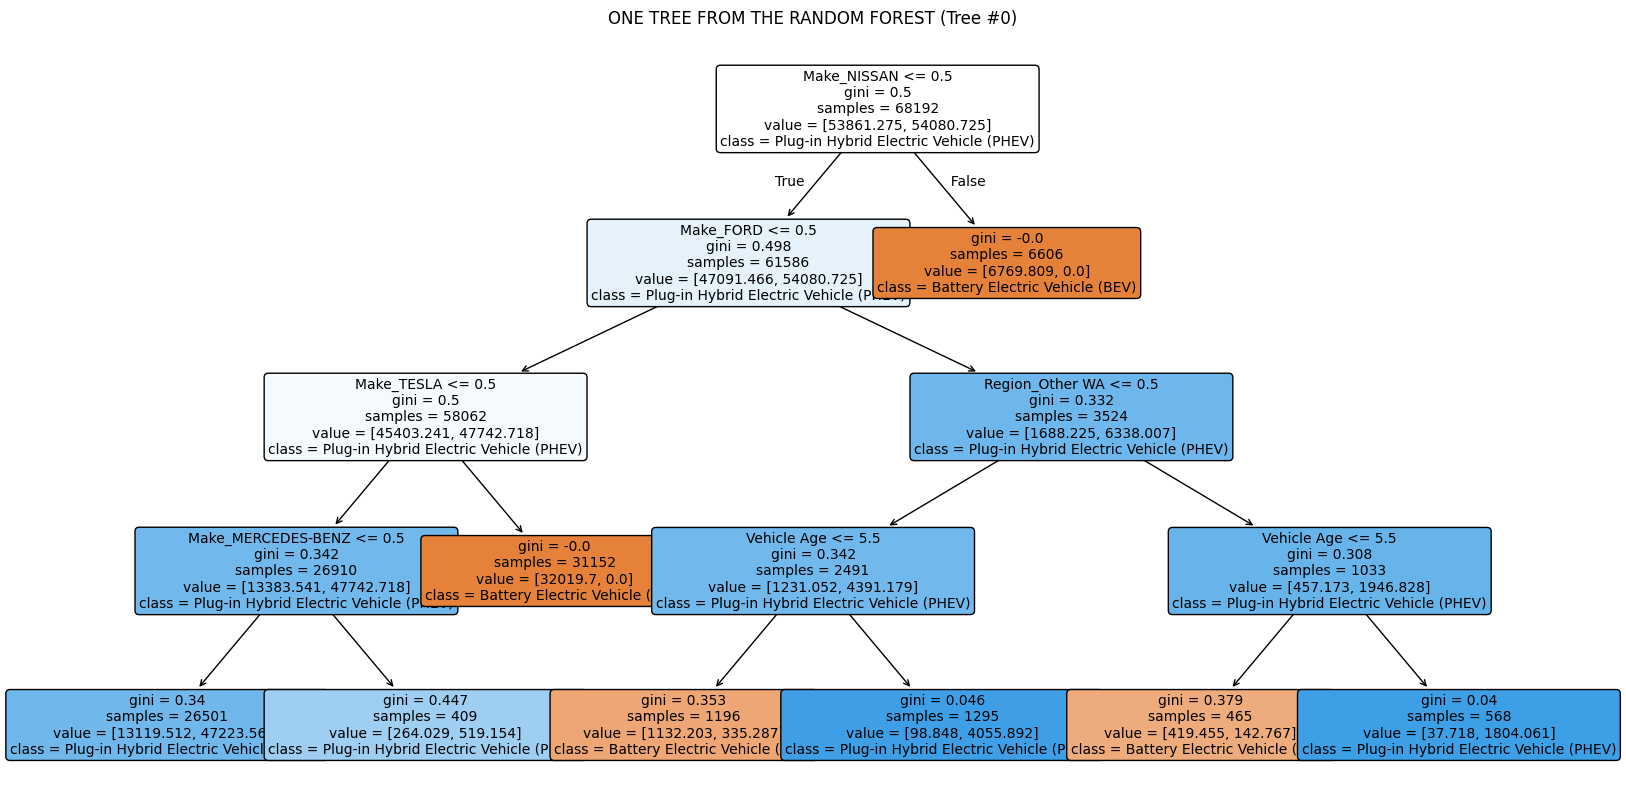

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Pick one tree out of the 100 in the forest — index 0 is just the first one
single_tree = forest.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(single_tree, feature_names=x.columns, class_names=y_encoder.classes_,
          filled=True, rounded=True, fontsize=10)
plt.title("ONE TREE FROM THE RANDOM FOREST (Tree #0)")
plt.show()